In [2]:
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting

corpus = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]} without {X[InIdiom=Yes];X[Idiom=Yes]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="coverage"
)

connected to port: 61072


Number of matches after filtering: 11701


In [3]:
import numpy as np
with open('x_65dims.npy', 'rb') as f:
    X = np.load(f)

In [4]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.utils import resample
from sklearn.metrics import jaccard_score

def bootstrap_stability(X, n_bootstrap=100, n_clusters=3, method='average', metric='euclidean'):
    """
    Perform stability assessment for hierarchical clustering using bootstrapping.
    
    Parameters:
        X (numpy.ndarray): Original data matrix (m rows, n columns).
        n_bootstrap (int): Number of bootstrap samples to generate.
        n_clusters (int): Number of clusters to form.
        method (str): Linkage method for hierarchical clustering.
        metric (str): Distance metric for pdist.
    
    Returns:
        float: Mean Jaccard index as a measure of clustering stability.
    """
    # Step 1: Perform clustering on the original data
    distance_matrix = pdist(X, metric=metric)
    linked = linkage(distance_matrix, method=method)
    C0 = fcluster(linked, n_clusters, criterion='maxclust')
    
    jaccard_indices = []
    
    # Step 2: Generate bootstrap samples and cluster them
    for _ in range(n_bootstrap):
        # Generate a bootstrap sample
        X_bootstrap = resample(X, replace=True, n_samples=X.shape[0])
        
        # Perform clustering on the bootstrap sample
        distance_matrix_bootstrap = pdist(X_bootstrap, metric=metric)
        linked_bootstrap = linkage(distance_matrix_bootstrap, method=method)
        Ci = fcluster(linked_bootstrap, n_clusters, criterion='maxclust')
        
        # Step 3: Compute Jaccard index between C0 and Ci
        # Align clusters by comparing each cluster in C0 with the most similar cluster in Ci
        jaccard_sum = 0
        for cluster_id in np.unique(C0):
            A = (C0 == cluster_id).astype(int)
            max_jaccard = 0
            for cluster_id_bootstrap in np.unique(Ci):
                B = (Ci == cluster_id_bootstrap).astype(int)
                max_jaccard = max(max_jaccard, jaccard_score(A, B))
            jaccard_sum += max_jaccard
        
        # Average Jaccard index for this bootstrap sample
        jaccard_indices.append(jaccard_sum / n_clusters)
    
    # Step 4: Compute the mean Jaccard index across all bootstrap samples
    mean_jaccard_index = np.mean(jaccard_indices)
    return mean_jaccard_index

# Example usage
# Assuming X is your data matrix with shape (129, 65)
for i in range(2, 11):
    mean_jaccard = bootstrap_stability(X, n_bootstrap=100, n_clusters=i)
    print(f"Mean Jaccard Index (Stability) for {i} clusters: {mean_jaccard}")
# mean_jaccard = bootstrap_stability(X, n_bootstrap=100, n_clusters=2)
# print(f"Mean Jaccard Index (Stability): {mean_jaccard}")

Mean Jaccard Index (Stability) for 2 clusters: 0.4892884094886807
Mean Jaccard Index (Stability) for 3 clusters: 0.3073782859284872
Mean Jaccard Index (Stability) for 4 clusters: 0.22759939499924414
Mean Jaccard Index (Stability) for 5 clusters: 0.1884567354338591
Mean Jaccard Index (Stability) for 6 clusters: 0.17731189798442665
Mean Jaccard Index (Stability) for 7 clusters: 0.1600068329874815
Mean Jaccard Index (Stability) for 8 clusters: 0.14903696889064533
Mean Jaccard Index (Stability) for 9 clusters: 0.14694062233651897
Mean Jaccard Index (Stability) for 10 clusters: 0.1384993610713355


In [25]:
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
link = ['single', 'average', 'complete']
red_dims = {}
for type_of_matrix in types_of_matrix:
    red_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    red_dims[type_of_matrix]['cosine']= {}
    for l in link:
        red_dims[type_of_matrix]['cosine'][l]= {}
        for i in range(2, 11):
            mean_jaccard = bootstrap_stability(X, n_bootstrap=100, n_clusters=i, method=l, metric='cosine')
            red_dims[type_of_matrix]['cosine'][l][i] = mean_jaccard
        

In [27]:
link = ['single', 'average', 'ward', 'complete', 'centroid']
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    red_dims[type_of_matrix]['euclidean']= {}
    for l in link:
        red_dims[type_of_matrix]['euclidean'][l]= {}
        for i in range(2, 11):
            mean_jaccard = bootstrap_stability(X, n_bootstrap=100, n_clusters=i, method=l, metric='euclidean')
            red_dims[type_of_matrix]['euclidean'][l][i] = mean_jaccard

In [28]:
red_dims

{'precision': {'cosine': {'single': {2: 0.496253106132053,
    3: 0.32801501377460823,
    4: 0.2477399246920591,
    5: 0.2081183348767632,
    6: 0.17485665740783626,
    7: 0.16225402697269822,
    8: 0.14768339222985907,
    9: 0.1452394672629448,
    10: 0.13780405333931547},
   'average': {2: 0.4943537272076102,
    3: 0.3187646519745888,
    4: 0.2439560939045074,
    5: 0.18826241317983108,
    6: 0.16501268932352903,
    7: 0.14790063964435135,
    8: 0.14008784770102403,
    9: 0.1345227917964151,
    10: 0.13288689390127156},
   'complete': {2: 0.392538271992199,
    3: 0.2503115681319408,
    4: 0.18476923129929165,
    5: 0.17010650044905115,
    6: 0.15022377307265228,
    7: 0.14112263128847868,
    8: 0.13763323215245957,
    9: 0.13520897599084652,
    10: 0.13088837544933554}},
  'euclidean': {'single': {2: 0.49350129459044567,
    3: 0.3362383853148173,
    4: 0.24998672976291048,
    5: 0.2218835505972085,
    6: 0.1972718662257768,
    7: 0.16505173962295175,
    8

In [29]:
link = ['single', 'average', 'complete']
orig_dims = {}
for type_of_matrix in types_of_matrix:
    orig_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    orig_dims[type_of_matrix]['cosine']= {}
    for l in link:
        orig_dims[type_of_matrix]['cosine'][l]= {}
        for i in range(2, 11):
            mean_jaccard = bootstrap_stability(X, n_bootstrap=100, n_clusters=i, method=l, metric='cosine')
            orig_dims[type_of_matrix]['cosine'][l][i] = mean_jaccard

In [30]:
link = ['single', 'average', 'ward', 'complete', 'centroid']
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    orig_dims[type_of_matrix]['euclidean']= {}
    for l in link:
        orig_dims[type_of_matrix]['euclidean'][l]= {}
        for i in range(2, 11):
            mean_jaccard = bootstrap_stability(X, n_bootstrap=100, n_clusters=i, method=l, metric='euclidean')
            orig_dims[type_of_matrix]['euclidean'][l][i] = mean_jaccard

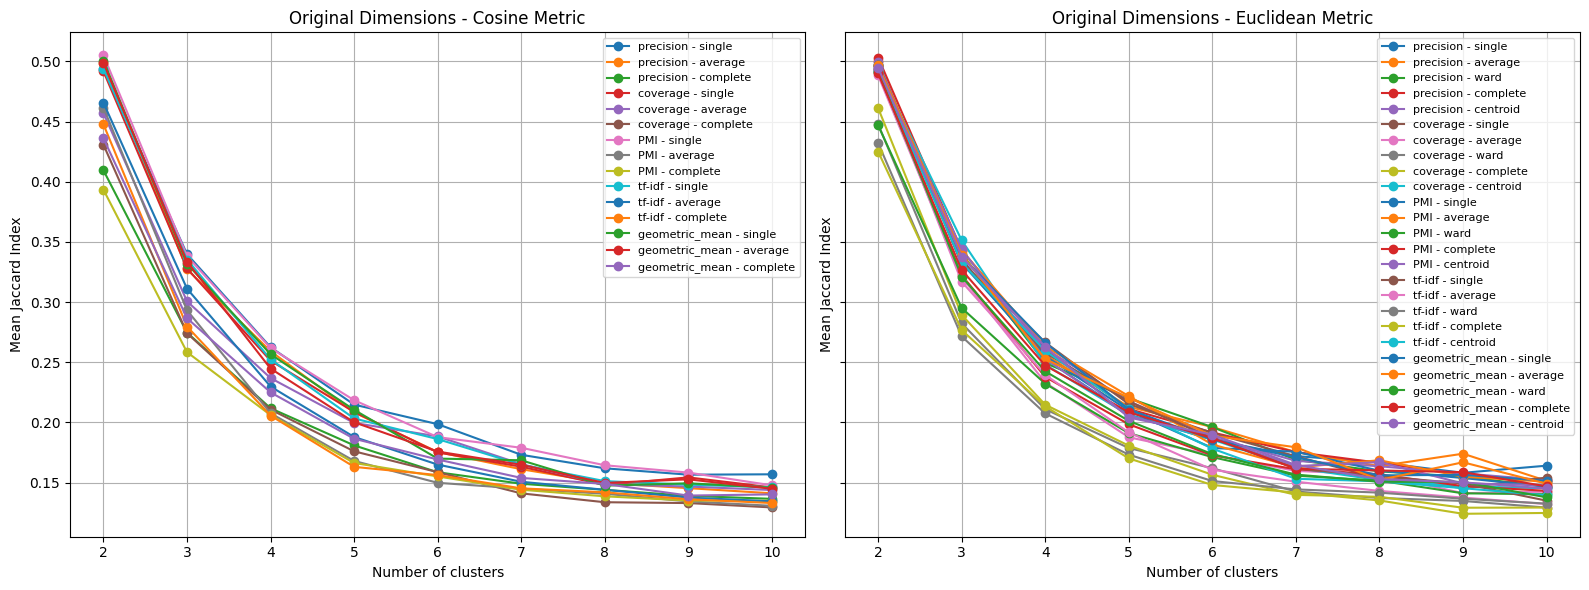

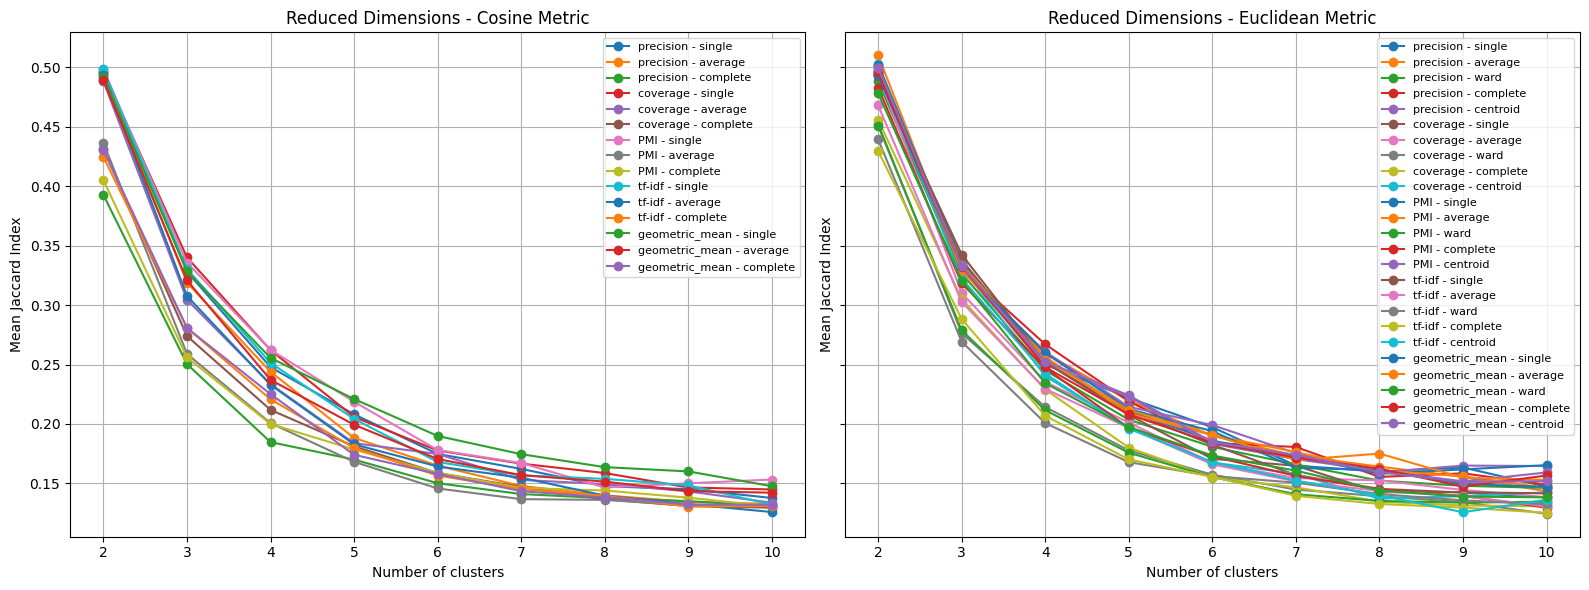

In [32]:
import matplotlib.pyplot as plt

def plot_stability(data, title_prefix):
    metrics = ['cosine', 'euclidean']
    matrix_types = list(data.keys())
    x = list(range(2, 11))
    
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    for idx, metric in enumerate(metrics):
        for mtype in matrix_types:
            if metric not in data[mtype]:
                continue
            for linkage in data[mtype][metric]:
                y = [data[mtype][metric][linkage][i] for i in x]
                axs[idx].plot(x, y, marker='o', label=f"{mtype} - {linkage}")
        axs[idx].set_title(f"{title_prefix} - {metric.capitalize()} Metric")
        axs[idx].set_xlabel('Number of clusters')
        axs[idx].set_ylabel('Mean Jaccard Index')
        axs[idx].legend(fontsize=8)
        axs[idx].grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot for original dimensions
plot_stability(orig_dims, "Original Dimensions")

# Plot for reduced dimensions
plot_stability(red_dims, "Reduced Dimensions")

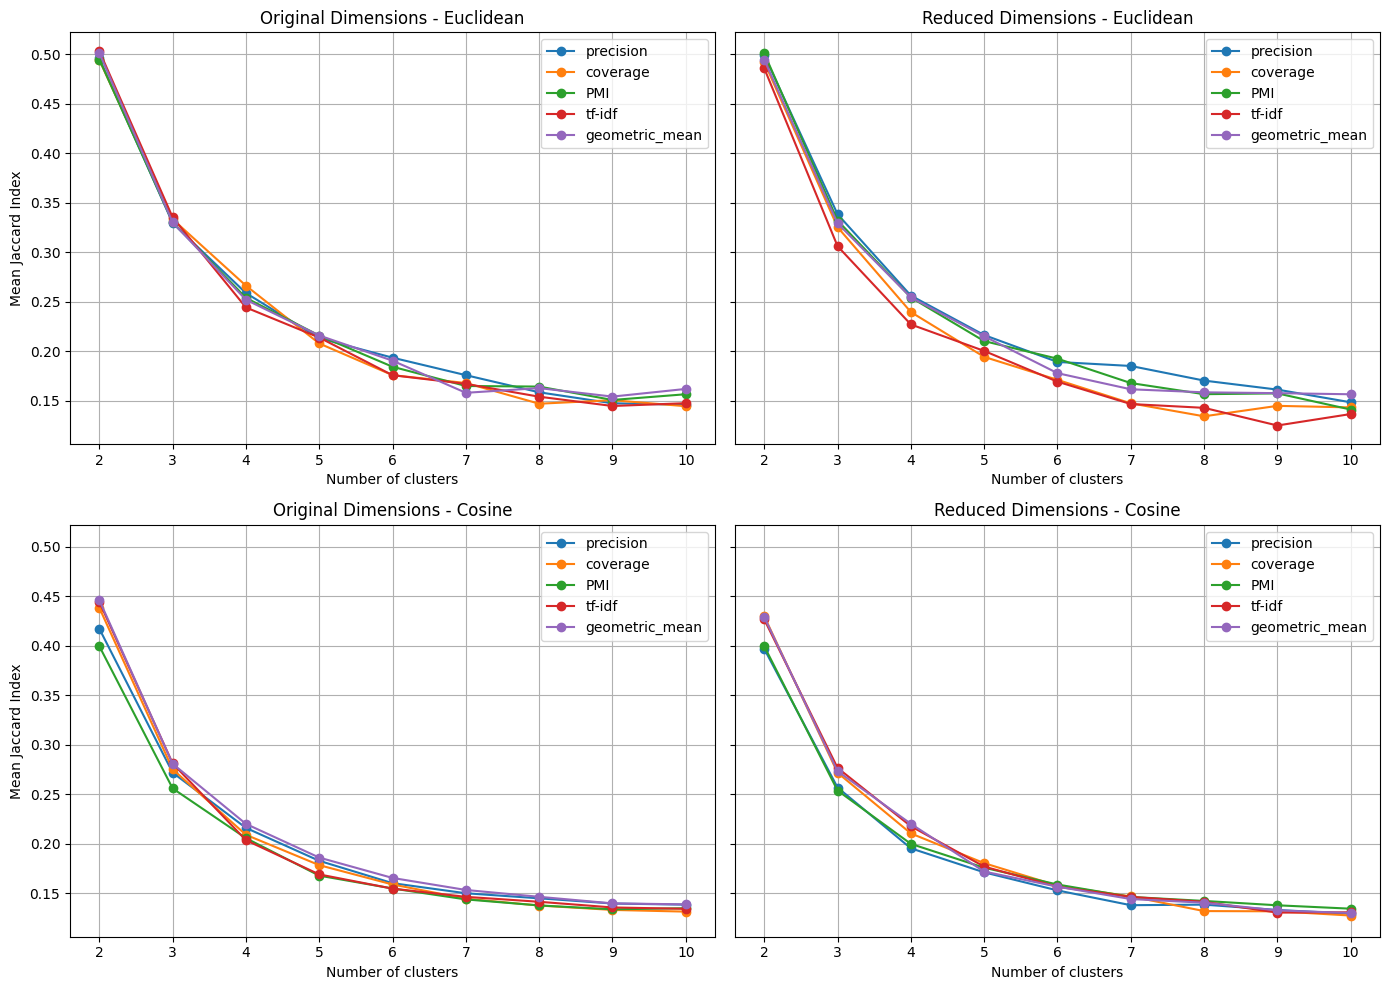

In [24]:
import matplotlib.pyplot as plt

x = list(range(2, 11))
matrix_types = list(orig_dims.keys())

fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

# 0,0: Original - Euclidean
for mtype in matrix_types:
    y = [orig_dims[mtype]["euclidean"][i] for i in x]
    axs[0, 0].plot(x, y, marker='o', label=mtype)
axs[0, 0].set_title('Original Dimensions - Euclidean')
axs[0, 0].set_xlabel('Number of clusters')
axs[0, 0].set_ylabel('Mean Jaccard Index')
axs[0, 0].legend()
axs[0, 0].grid(True)

# 0,1: Reduced - Euclidean
for mtype in matrix_types:
    y = [red_dims[mtype]["euclidean"][i] for i in x]
    axs[0, 1].plot(x, y, marker='o', label=mtype)
axs[0, 1].set_title('Reduced Dimensions - Euclidean')
axs[0, 1].set_xlabel('Number of clusters')
axs[0, 1].legend()
axs[0, 1].grid(True)

# 1,0: Original - Cosine
for mtype in matrix_types:
    y = [orig_dims[mtype]["cosine"][i] for i in x]
    axs[1, 0].plot(x, y, marker='o', label=mtype)
axs[1, 0].set_title('Original Dimensions - Cosine')
axs[1, 0].set_xlabel('Number of clusters')
axs[1, 0].set_ylabel('Mean Jaccard Index')
axs[1, 0].legend()
axs[1, 0].grid(True)

# 1,1: Reduced - Cosine
for mtype in matrix_types:
    y = [red_dims[mtype]["cosine"][i] for i in x]
    axs[1, 1].plot(x, y, marker='o', label=mtype)
axs[1, 1].set_title('Reduced Dimensions - Cosine')
axs[1, 1].set_xlabel('Number of clusters')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
from sklearn.cluster import KMeans
from sklearn.utils import resample
from sklearn.metrics import jaccard_score
import numpy as np

def bootstrap_stability_kmeans(X, n_bootstrap=100, n_clusters=3, random_state=None):
    """
    Perform stability assessment for k-means clustering using bootstrapping.
    
    Parameters:
        X (numpy.ndarray): Original data matrix (m rows, n columns).
        n_bootstrap (int): Number of bootstrap samples to generate.
        n_clusters (int): Number of clusters to form.
        random_state (int or None): Random state for reproducibility.
    
    Returns:
        float: Mean Jaccard index as a measure of clustering stability.
    """
    # Step 1: Perform k-means clustering on the original data
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    C0 = kmeans.fit_predict(X)
    
    jaccard_indices = []
    
    # Step 2: Generate bootstrap samples and cluster them
    for _ in range(n_bootstrap):
        # Generate a bootstrap sample
        X_bootstrap = resample(X, replace=True, n_samples=X.shape[0], random_state=random_state)
        
        # Perform k-means clustering on the bootstrap sample
        kmeans_bootstrap = KMeans(n_clusters=n_clusters, random_state=random_state)
        Ci = kmeans_bootstrap.fit_predict(X_bootstrap)
        
        # Step 3: Compute Jaccard index between C0 and Ci
        # Align clusters by comparing each cluster in C0 with the most similar cluster in Ci
        jaccard_sum = 0
        for cluster_id in np.unique(C0):
            A = (C0 == cluster_id).astype(int)
            max_jaccard = 0
            for cluster_id_bootstrap in np.unique(Ci):
                B = (Ci == cluster_id_bootstrap).astype(int)
                max_jaccard = max(max_jaccard, jaccard_score(A, B))
            jaccard_sum += max_jaccard
        
        # Average Jaccard index for this bootstrap sample
        jaccard_indices.append(jaccard_sum / n_clusters)
    
    # Step 4: Compute the mean Jaccard index across all bootstrap samples
    mean_jaccard_index = np.mean(jaccard_indices)
    return mean_jaccard_index

# Example usage
# Assuming X is your data matrix with shape (129, 65)
for i in range(2, 11):
    mean_jaccard_kmeans = bootstrap_stability_kmeans(X, n_bootstrap=100, n_clusters=i, random_state=42)
    print(f"Mean Jaccard Index (Stability) for K-Means with {i} clusters: {mean_jaccard_kmeans}")
# mean_jaccard_kmeans = bootstrap_stability_kmeans(X, n_bootstrap=100, n_clusters=2, random_state=42)
# print(f"Mean Jaccard Index (Stability) for K-Means: {mean_jaccard_kmeans}")

Mean Jaccard Index (Stability) for K-Means with 2 clusters: 0.44527793141592925
Mean Jaccard Index (Stability) for K-Means with 3 clusters: 0.2925864161883773
Mean Jaccard Index (Stability) for K-Means with 4 clusters: 0.22930100743346896
Mean Jaccard Index (Stability) for K-Means with 5 clusters: 0.17982407688929425
Mean Jaccard Index (Stability) for K-Means with 6 clusters: 0.1505969514905327
Mean Jaccard Index (Stability) for K-Means with 7 clusters: 0.14552549580581853
Mean Jaccard Index (Stability) for K-Means with 8 clusters: 0.12495336435382348
Mean Jaccard Index (Stability) for K-Means with 9 clusters: 0.13286184339360355
Mean Jaccard Index (Stability) for K-Means with 10 clusters: 0.1271685628824412


In [6]:
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
red_dims = {}
for type_of_matrix in types_of_matrix:
    red_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    for i in range(2, 11):
        red_dims[type_of_matrix][i] = {}
        mean_jaccard_kmeans = bootstrap_stability_kmeans(X, n_bootstrap=100, n_clusters=i, random_state=42)
        red_dims[type_of_matrix][i] = mean_jaccard_kmeans

In [8]:
orig_dims = {}
for type_of_matrix in types_of_matrix:
    orig_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    for i in range(2, 11):
        orig_dims[type_of_matrix][i] = {}
        mean_jaccard_kmeans = bootstrap_stability_kmeans(X, n_bootstrap=100, n_clusters=i, random_state=42)
        orig_dims[type_of_matrix][i] = mean_jaccard_kmeans

In [9]:
orig_dims

{'precision': {2: 0.4923091008972716,
  3: 0.3206218221221972,
  4: 0.23865570051049345,
  5: 0.18950311348328888,
  6: 0.15552325581395346,
  7: 0.1312949302700978,
  8: 0.17454769736842107,
  9: 0.15526011208576998,
  10: 0.1391108960176992},
 'coverage': {2: 0.4448122082084873,
  3: 0.2924632165957625,
  4: 0.20283380054474862,
  5: 0.17779194465035836,
  6: 0.1612953573440612,
  7: 0.15178833071690215,
  8: 0.1499664888251844,
  9: 0.13645967559011038,
  10: 0.153240769708161},
 'PMI': {2: 0.4944454617591407,
  3: 0.3219383146212414,
  4: 0.23465085638998676,
  5: 0.19841054325021346,
  6: 0.15923960493288228,
  7: 0.15069912692145812,
  8: 0.10594190747920393,
  9: 0.13359317201681736,
  10: 0.1257886804056159},
 'tf-idf': {2: 0.44081858407079644,
  3: 0.291713001575387,
  4: 0.2064333152615885,
  5: 0.19538329996104498,
  6: 0.1474186655638268,
  7: 0.1537382260596547,
  8: 0.14488991112516303,
  9: 0.13868891386154816,
  10: 0.14204806191251199},
 'geometric_mean': {2: 0.4923091

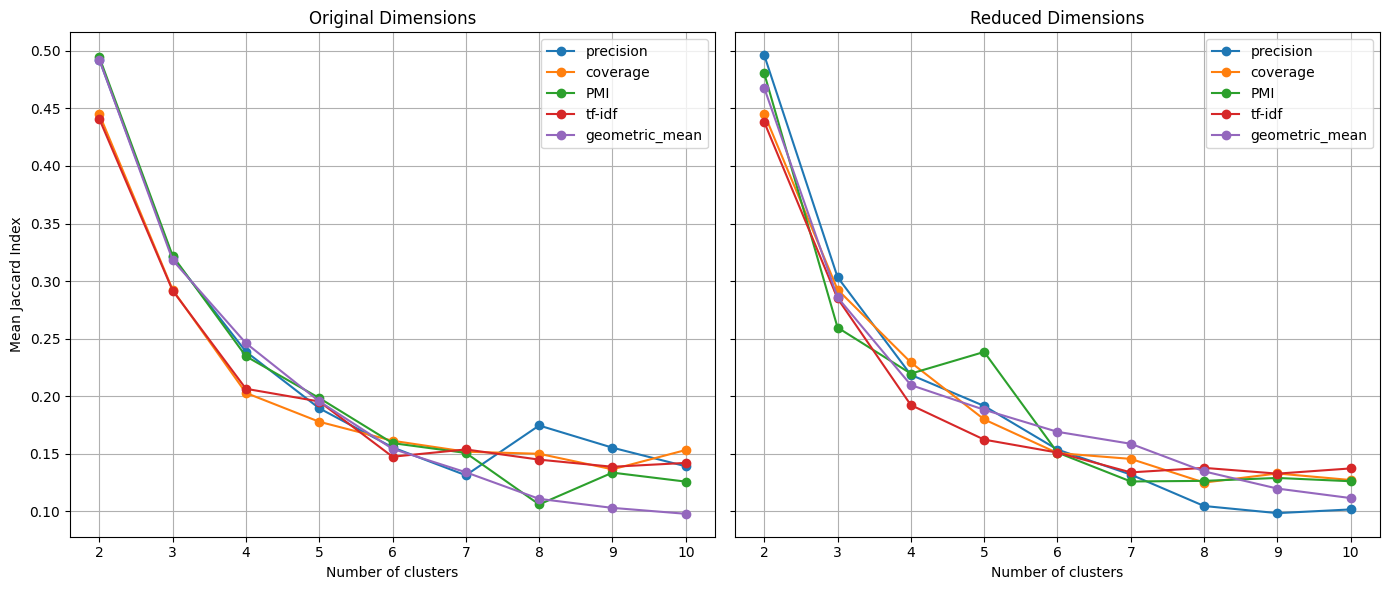

In [10]:
import matplotlib.pyplot as plt

x = list(range(2, 11))
matrix_types = list(orig_dims.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for original dimensions
for mtype in matrix_types:
    y = [orig_dims[mtype][i] for i in x]
    axs[0].plot(x, y, marker='o', label=mtype)
axs[0].set_title('Original Dimensions')
axs[0].set_xlabel('Number of clusters')
axs[0].set_ylabel('Mean Jaccard Index')
axs[0].legend()
axs[0].grid(True)

# Plot for reduced dimensions
for mtype in matrix_types:
    y = [red_dims[mtype][i] for i in x]
    axs[1].plot(x, y, marker='o', label=mtype)
axs[1].set_title('Reduced Dimensions')
axs[1].set_xlabel('Number of clusters')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()